# 🎬 Movie Review Sentiment Analysis Using NLP

### Project Objective
Build a machine learning system that classifies a movie review as **Positive** or **Negative**.

### Workflow
1. Import all libraries  
2. Load the dataset  
3. Understand the data  
4. Clean the data  
5. Preprocessing  
6. Encoding / Text Vectorization  
7. X-Y Split  
8. Machine Learning Models  
9. Evaluation  
10. Deployment with Streamlit

> **Dataset:** IMDB Movie Reviews  
> **Target:** `sentiment` → Positive / Negative

## 1. Import All Libraries

We import the libraries required for:
- Data handling → Pandas, NumPy
- Visualization → Matplotlib, Seaborn
- Text processing → NLTK, Regular Expressions
- Feature extraction → TF-IDF
- Machine learning → Scikit-learn
- Model saving → Joblib

In [1]:
# Data handling
import os
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Text preprocessing
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Save/load trained objects
import joblib

# Display settings
pd.set_option("display.max_colwidth", 200)
sns.set_theme(style="whitegrid")

print("All libraries imported successfully.")


All libraries imported successfully.


### Download NLTK Resources

These resources are used for stopword removal and lemmatization.

In [2]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

print("NLTK resources are ready.")

NLTK resources are ready.


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\sanka\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\sanka\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\sanka\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


## 2. Load the Dataset

Keep **`IMDB Dataset.csv`** in the same folder as this notebook.

The dataset should contain:
- `review` → movie review text
- `sentiment` → positive or negative label


In [3]:
# Dataset file
# Keep "IMDB Dataset.csv" in the same folder as this notebook.
DATA_PATH = "IMDB Dataset.csv"

if not os.path.exists(DATA_PATH):
    print("Dataset file not found.")
    print("Please place 'IMDB Dataset.csv' in the same folder as this notebook,")
    print("then run this cell again.")
else:
    df = pd.read_csv(DATA_PATH)
    print("Dataset loaded successfully!")
    print("Rows:", df.shape[0])
    print("Columns:", df.shape[1])


Dataset loaded successfully!
Rows: 50000
Columns: 2


## 3. Understand the Data

First, inspect the structure, columns, data types, missing values, duplicates, and target distribution.

In [5]:
# First 5 rows
df.head()

,review,sentiment
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me...",positive
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire p...",positive
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue i...",positive
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenl...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what mone...",positive


In [4]:
# Dataset dimensions
print("Shape:", df.shape)

Shape: (50000, 2)


In [5]:
# Column names
print("Columns:", df.columns.tolist())

Columns: ['review', 'sentiment']


In [6]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
# Missing values
print(df.isnull().sum())

review       0
sentiment    0
dtype: int64


In [8]:
# Duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 418


In [10]:
# Target distribution
print(df["sentiment"].value_counts())

sentiment
positive    25000
negative    25000
Name: count, dtype: int64


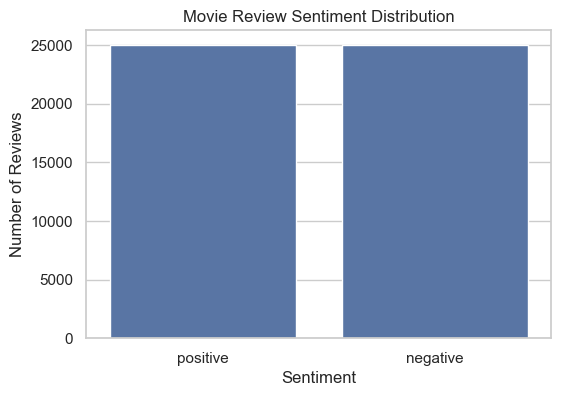

In [11]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="sentiment")
plt.title("Movie Review Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Reviews")
plt.show()

## 4. Clean the Data

Cleaning removes duplicate reviews and handles missing values.

We also remove unnecessary whitespace from the text.

In [12]:
# Remove rows with missing review or sentiment
df = df.dropna(subset=["review", "sentiment"]).copy()

# Remove duplicate rows
df = df.drop_duplicates().copy()

# Remove leading/trailing spaces
df["review"] = df["review"].str.strip()

print("Shape after cleaning:", df.shape)
print("Missing values:")
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

Shape after cleaning: (49582, 2)
Missing values:
review       0
sentiment    0
dtype: int64
Duplicates: 0


### Review Length Analysis

Review length helps us understand the text data before preprocessing.

In [13]:
df["review_length"] = df["review"].str.len()

df["review_length"].describe()

count    49582.000000
mean      1310.566657
std        990.760997
min         32.000000
25%        699.000000
50%        971.000000
75%       1592.000000
max      13704.000000
Name: review_length, dtype: float64

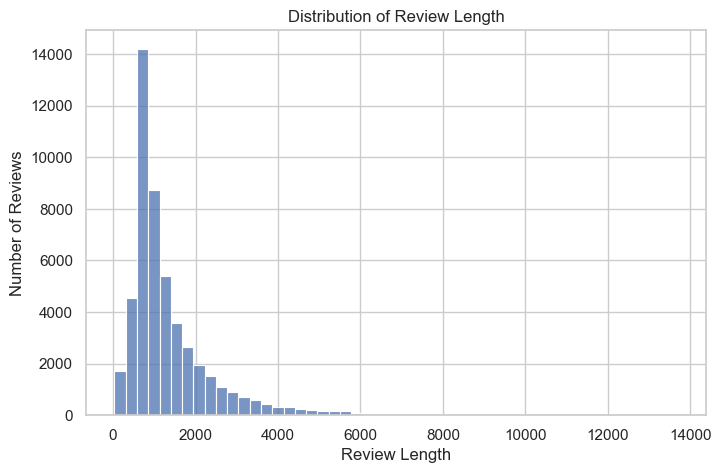

In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(df["review_length"], bins=50)
plt.title("Distribution of Review Length")
plt.xlabel("Review Length")
plt.ylabel("Number of Reviews")
plt.show()

## 5. Preprocessing

The text is converted into a cleaner form:
1. Convert to lowercase
2. Remove HTML tags
3. Remove special characters and numbers
4. Split text into words
5. Remove English stopwords
6. Apply lemmatization

This reduces unnecessary variation in the text.

In [15]:
# Prepare NLP tools
stop_words = set(stopwords.words("english"))

# Keep negation words because they are useful for sentiment analysis.
stop_words.discard("no")
stop_words.discard("not")
stop_words.discard("nor")

lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    # Convert to string and lowercase
    text = str(text).lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Keep only English letters and spaces
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenization
    words = text.split()

    # Stopword removal + lemmatization
    cleaned_words = []
    for word in words:
        if word not in stop_words:
            cleaned_words.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned_words)

print("Preprocessing function created.")


Preprocessing function created.


In [16]:
# Apply preprocessing
df["clean_review"] = df["review"].apply(preprocess_text)

# Compare original and cleaned reviews
df[["review", "clean_review"]].head()

,review,clean_review
0,"One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me...",one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust not show faint hearted timid show pull n...
1,"A wonderful little production. <br /><br />The filming technique is very unassuming- very old-time-BBC fashion and gives a comforting, and sometimes discomforting, sense of realism to the entire p...",wonderful little production filming technique unassuming old time bbc fashion give comforting sometimes discomforting sense realism entire piece actor extremely well chosen michael sheen not got p...
2,"I thought this was a wonderful way to spend time on a too hot summer weekend, sitting in the air conditioned theater and watching a light-hearted comedy. The plot is simplistic, but the dialogue i...",thought wonderful way spend time hot summer weekend sitting air conditioned theater watching light hearted comedy plot simplistic dialogue witty character likable even well bread suspected serial ...
3,Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenl...,basically family little boy jake think zombie closet parent fighting time movie slower soap opera suddenly jake decides become rambo kill zombie ok first going make film must decide thriller drama...
4,"Petter Mattei's ""Love in the Time of Money"" is a visually stunning film to watch. Mr. Mattei offers us a vivid portrait about human relations. This is a movie that seems to be telling us what mone...",petter mattei love time money visually stunning film watch mr mattei offer u vivid portrait human relation movie seems telling u money power success people different situation encounter variation ...


## 6. Encoding / Text Vectorization

Machine learning models cannot directly understand raw text.

We convert text into numerical features using **TF-IDF (Term Frequency–Inverse Document Frequency)**.

> TF-IDF is a **text vectorization technique**, not a neural-network embedding. It gives higher importance to words that are useful for distinguishing reviews.

In [17]:
# Convert sentiment labels to numbers
df["sentiment_encoded"] = df["sentiment"].map({
    "negative": 0,
    "positive": 1
})

print(df[["sentiment", "sentiment_encoded"]].drop_duplicates())

  sentiment  sentiment_encoded
0  positive                  1
3  negative                  0


### Create X and y Before Vectorization

- **X** = cleaned movie reviews
- **y** = sentiment label

In [18]:
X_text = df["clean_review"]
y = df["sentiment_encoded"]

print("X samples:", len(X_text))
print("y samples:", len(y))

X samples: 49582
y samples: 49582


## 7. X-Y Split

We split the dataset into:
- **80% training data**
- **20% testing data**

`stratify=y` keeps the positive/negative class proportion similar in both sets.

The TF-IDF vectorizer is fitted **only on training data** to avoid data leakage.

In [19]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples :", len(X_test_text))

Training samples: 39665
Testing samples : 9917


In [20]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    sublinear_tf=True
)

X_train = vectorizer.fit_transform(X_train_text)
X_test = vectorizer.transform(X_test_text)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

X_train shape: (39665, 5000)
X_test shape : (9917, 5000)


## 8. Machine Learning Models

We train and compare four supervised learning algorithms:
1. Logistic Regression
2. Multinomial Naive Bayes
3. Linear SVM
4. Random Forest

For IMDB text classification, **Linear SVM and Logistic Regression** are strong baseline choices for TF-IDF features.

In [21]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC(),
    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    )
}

trained_models = {}
predictions = {}
results = []

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, pred)

    trained_models[name] = model
    predictions[name] = pred
    results.append({
        "Model": name,
        "Accuracy": accuracy
    })

    print(f"{name} Accuracy: {accuracy:.4f}\n")

results = pd.DataFrame(results).sort_values(
    by="Accuracy",
    ascending=False
).reset_index(drop=True)

results

Training Logistic Regression...
Logistic Regression Accuracy: 0.8955

Training Naive Bayes...
Naive Bayes Accuracy: 0.8651

Training SVM...
SVM Accuracy: 0.8853

Training Random Forest...
Random Forest Accuracy: 0.8478



,Model,Accuracy
0,Logistic Regression,0.895533
1,SVM,0.885348
2,Naive Bayes,0.865080
3,Random Forest,0.847837


## 9. Evaluation

We evaluate the models using:
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

The best model is selected based on the test performance.

In [24]:
# Model comparison
results_display = results.copy()
results_display["Accuracy (%)"] = results_display["Accuracy"] * 100
results_display


,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.895533,89.553292
1,SVM,0.885348,88.534839
2,Naive Bayes,0.865080,86.508017
3,Random Forest,0.847837,84.783705


,Model,Accuracy (%)
0,Logistic Regression,89.553292
1,SVM,88.534839
2,Naive Bayes,86.508017
3,Random Forest,84.783705


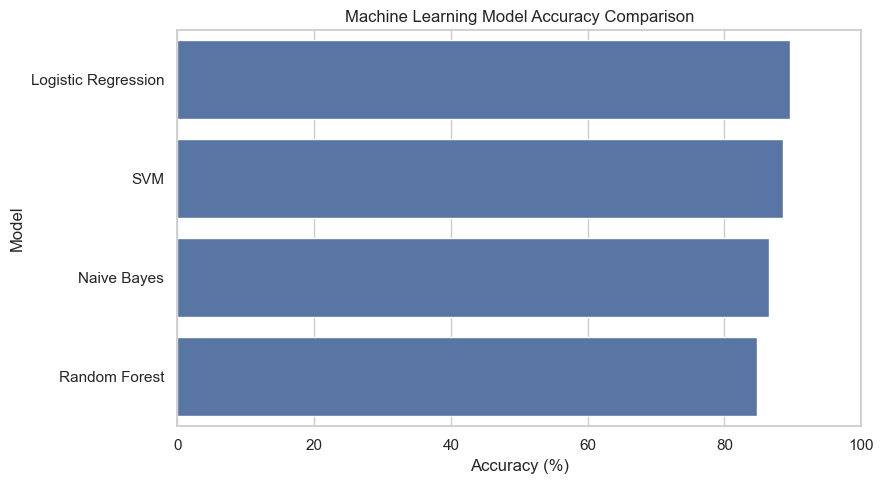

In [26]:
##### Model Accuracy Comparison

# Convert accuracy to percentage
results["Accuracy (%)"] = results["Accuracy"] * 100

# Display results
display(results[["Model", "Accuracy (%)"]])

# Plot model accuracy
plt.figure(figsize=(9, 5))

sns.barplot(
    data=results,
    x="Accuracy (%)",
    y="Model"
)

plt.title("Machine Learning Model Accuracy Comparison")
plt.xlabel("Accuracy (%)")
plt.ylabel("Model")
plt.xlim(0, 100)

plt.tight_layout()
plt.show()

In [27]:
# Select the best model
best_model_name = results.loc[0, "Model"]
best_model = trained_models[best_model_name]
best_pred = predictions[best_model_name]

print("Best Model:", best_model_name)
print(f"Best Accuracy: {results.loc[0, 'Accuracy'] * 100:.2f}%")


Best Model: Logistic Regression
Best Accuracy: 89.55%


In [28]:
# Classification report
print(f"Classification Report - {best_model_name}\n")
print(
    classification_report(
        y_test,
        best_pred,
        target_names=["Negative", "Positive"]
    )
)

Classification Report - Logistic Regression

              precision    recall  f1-score   support

    Negative       0.90      0.88      0.89      4940
    Positive       0.89      0.91      0.90      4977

    accuracy                           0.90      9917
   macro avg       0.90      0.90      0.90      9917
weighted avg       0.90      0.90      0.90      9917



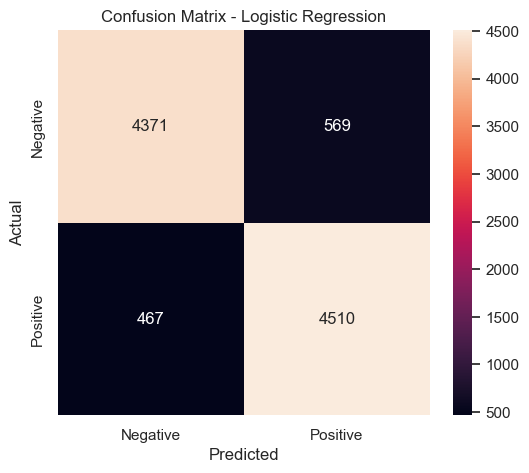

In [29]:
# Confusion matrix
cm = confusion_matrix(y_test, best_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_model_name}")
plt.show()

### Test the Sentiment Prediction

We can give a new movie review to the trained model and predict whether it is positive or negative.

In [30]:
def predict_sentiment(review):
    cleaned_review = preprocess_text(review)
    review_tfidf = vectorizer.transform([cleaned_review])
    prediction = best_model.predict(review_tfidf)[0]

    return "Positive" if prediction == 1 else "Negative"

test_reviews = [
    "The movie was fantastic and the acting was excellent.",
    "The movie was extremely boring and disappointing."
]

for review in test_reviews:
    print("Review:", review)
    print("Predicted Sentiment:", predict_sentiment(review))
    print()


Review: The movie was fantastic and the acting was excellent.
Predicted Sentiment: Positive

Review: The movie was extremely boring and disappointing.
Predicted Sentiment: Negative



## 10. Deploy with Streamlit

To deploy the model, save:
- The trained ML model
- The TF-IDF vectorizer

Then create a Streamlit application with a text box and prediction button.

In [31]:
# Save the trained model and TF-IDF vectorizer
joblib.dump(best_model, "best_model.pkl")
joblib.dump(vectorizer, "tfidf_vectorizer.pkl")

print("Model saved as: best_model.pkl")
print("Vectorizer saved as: tfidf_vectorizer.pkl")
print("Files saved successfully!")


Model saved as: best_model.pkl
Vectorizer saved as: tfidf_vectorizer.pkl
Files saved successfully!


### Create `app.py`

The notebook creates **`app.py`** in the same folder as:
- `best_model.pkl`
- `tfidf_vectorizer.pkl`

Run the application from a terminal using:

```bash
streamlit run app.py
```


In [32]:
%%writefile app.py

import re
import joblib
import streamlit as st
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Load model and vectorizer
model = joblib.load("best_model.pkl")
vectorizer = joblib.load("tfidf_vectorizer.pkl")

# Prepare NLP tools
stop_words = set(stopwords.words("english"))
stop_words.discard("no")
stop_words.discard("not")
stop_words.discard("nor")
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    text = str(text).lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    words = text.split()
    cleaned_words = []

    for word in words:
        if word not in stop_words:
            cleaned_words.append(lemmatizer.lemmatize(word))

    return " ".join(cleaned_words)

st.set_page_config(page_title="Movie Review Sentiment Analysis", page_icon="🎬")

st.title("🎬 Movie Review Sentiment Analysis")
st.write("Enter a movie review to predict whether it is Positive or Negative.")

review = st.text_area("Enter your movie review:")

if st.button("Predict Sentiment"):
    if review.strip():
        cleaned_review = preprocess_text(review)
        review_vector = vectorizer.transform([cleaned_review])
        prediction = model.predict(review_vector)[0]

        if prediction == 1:
            st.success("😊 Positive Review")
        else:
            st.error("😞 Negative Review")
    else:
        st.warning("Please enter a review.")


Writing app.py


In [33]:
# Do not run Streamlit with a blocking shell command inside the notebook.
# Open a terminal in this notebook's folder and run:
#
# streamlit run app.py
#
# The browser will open the Streamlit application.
print("Streamlit app.py has been created.")
print("Run 'streamlit run app.py' in a terminal to start the application.")


Streamlit app.py has been created.
Run 'streamlit run app.py' in a terminal to start the application.


## Project Conclusion

The project follows a complete machine learning pipeline:

**Dataset → Data Understanding → Cleaning → Text Preprocessing → TF-IDF Vectorization → Train/Test Split → ML Models → Evaluation → Streamlit Deployment**

The system can automatically classify a movie review as **Positive** or **Negative**.

### Key Points
- Duplicate and missing data were handled.
- Text was cleaned using NLP preprocessing.
- TF-IDF converted reviews into numerical features.
- Multiple supervised ML models were compared.
- The best-performing model was selected using test accuracy.
- The trained model and vectorizer were saved for Streamlit deployment.